In [35]:
import os, sys, numpy as np, pandas as pd, warnings
import argparse
import time
from typing import Optional, Set, List
from datetime import datetime
import pyarrow.parquet as pq

from typing import Dict, Tuple, Optional
try:
    from scipy.stats import genextreme, kstest, probplot, genpareto, lomax
    SCIPY_OK = True
except Exception:
    SCIPY_OK = False

try:
    import matplotlib.pyplot as plt
    MPL_OK = True
except Exception:
    MPL_OK = False

# === EVT without trimming: Full-data GEV + Tail GPD (Pareto) + (optional) whole-data Lomax ===



current_datetime = datetime.now().strftime("%Y%m%d-%H%M")

In [36]:
METRICS      = ("producer_consumer", "consumer_application")
SCOPES       = ("global") #, "consumer_pod", "producer_pod")
SCOPE        = "global"
Home         = "/Users/soheila/Desktop/RealTime-Streaming-Pipeline/results"
RUN_STAMP    = "20250908_140639"             
PARQUET_ROOT = os.path.join(Home, RUN_STAMP, "consumer", "consumer-sts-0_consumer-result/processed/2025-09-08")
metrics_dir  = os.path.join(Home, RUN_STAMP, "merge", "merge-sts-0_merge-metrics/2025-09-08_00-57-10")
plots_dir    = os.path.join( Home, "plots", current_datetime)
os.makedirs(plots_dir, exist_ok=True)
block_path   = os.path.join(metrics_dir, "block_maxima.csv")
trim_levels  = [0.00, 0.01, 0.02, 0.05, 0.07, 0.10] 
plots_dir

'/Users/soheila/Desktop/RealTime-Streaming-Pipeline/results/plots/20250909-1904'

In [37]:
# -----------------------------
# Helpers
# -----------------------------
def list_parquet_files(root: str):
    out = []
    for r, _, fs in os.walk(root):
        for f in fs:
            if f.endswith(".parquet") and not f.startswith(".tmp_"):
                out.append(os.path.join(r, f))
    return sorted(out)


In [38]:
len(list_parquet_files(PARQUET_ROOT))

3919

In [39]:
def load_parquet_columns(parquet_path: str, needed_cols):
    needed = set(needed_cols)
    try:
        have = set(pq.read_schema(parquet_path).names)
        cols = list(needed & have)
        if not cols:
            return pd.DataFrame()
        return pd.read_parquet(parquet_path, columns=cols)
    except Exception:
        try:
            df = pd.read_parquet(parquet_path)
            keep = list(needed & set(df.columns))
            return df[keep] if keep else pd.DataFrame()
        except Exception as e2:
            print(f"[ERROR] Failed to read {os.path.basename(parquet_path)}: {e2}")
            return None

In [40]:
needed = { 
        "producer_timestamp", "consumer_receive_timestamp",
        "application_timestamp", "application_latency_seconds",
        "end_to_end_latency_seconds", "target_rate" , 
        "producer_pod", "consumer_pod",
    }

In [41]:
df = load_parquet_columns(PARQUET_ROOT , needed)

In [44]:
df

,application_timestamp,consumer_receive_timestamp,producer_timestamp,consumer_pod,target_rate,application_latency_seconds,producer_pod,end_to_end_latency_seconds
0,1.757315e+09,1.757315e+09,1.757315e+09,consumer-sts-0,250.0,0.013615,producer-sts-0,5.659681
1,1.757315e+09,1.757315e+09,1.757315e+09,consumer-sts-0,250.0,0.019734,producer-sts-0,5.506900
2,1.757315e+09,1.757315e+09,1.757315e+09,consumer-sts-0,250.0,0.019549,producer-sts-0,5.454288
3,1.757315e+09,1.757315e+09,1.757315e+09,consumer-sts-0,250.0,0.018913,producer-sts-0,5.280153
4,1.757315e+09,1.757315e+09,1.757315e+09,consumer-sts-0,250.0,0.017971,producer-sts-0,5.247118
...,...,...,...,...,...,...,...,...
19594995,1.757360e+09,1.757360e+09,1.757360e+09,consumer-sts-9,250.0,0.019372,producer-sts-3,0.511553
19594996,1.757360e+09,1.757360e+09,1.757360e+09,consumer-sts-9,250.0,0.012640,producer-sts-3,0.495214
19594997,1.757360e+09,1.757360e+09,1.757360e+09,consumer-sts-9,250.0,0.017250,producer-sts-0,0.480969
19594998,1.757360e+09,1.757360e+09,1.757360e+09,consumer-sts-9,250.0,0.014153,producer-sts-3,0.468372


In [20]:
#df["target_rate"].unique()[0]

In [42]:
# -----------------------------
# Load Parquet Files
# -----------------------------
def build_block_metadata_map(root_dir):
    """
    Returns a DataFrame indexed by block_id (filename sans .parquet)
    with at least the column 'target_rate' (mode per file).
    """
    files = list_parquet_files(root_dir)
    rows = []
    for p in files:
        try:
            df = pd.read_parquet(p, columns=["target_rate"])
        except Exception:
            # fallback: read all, then subset if present
            try:
                df = pd.read_parquet(p)
            except Exception:
                continue
        if "target_rate" not in df.columns or df["target_rate"].dropna().empty:
            continue
        tr = pd.to_numeric(df["target_rate"], errors="coerce").dropna()
        if tr.empty:
            continue
        block_id = os.path.splitext(os.path.basename(p))[0]
        rows.append({"block_id": block_id, "target_rate": float(tr.mode().iloc[0])})
    if not rows:
        return pd.DataFrame()
    md = pd.DataFrame(rows).drop_duplicates("block_id").set_index("block_id")
    return md
    


In [43]:
# -----------------------------
# Load block_maxima
# -----------------------------
if not os.path.exists(block_path):
    raise FileNotFoundError(f"block_maxima.csv not found at: {block_path}")

block_df = pd.read_csv(block_path)
CAP_S    = 5
block_df =block_df[(block_df["block_max_value"] >= 0) & (block_df["block_max_value"] <= CAP_S)].copy()
block_df.columns


Index(['file_name', 'computed_at', 'metric', 'scope', 'pod', 'block_max_value',
       'rows_in_block', 'config_hash'],
      dtype='object')

In [ ]:
block_df

In [22]:
# Add a block_id to parquet data frame
if "block_id" not in block_df.columns:
    if "file_name" not in block_df.columns:
        raise ValueError("block_maxima.csv missing both 'block_id' and 'file_name'.")
    block_df["block_id"] = (
        block_df["file_name"].astype(str).str.replace(r"\.parquet$", "", regex=True)
    )
    print("[INFO] Derived block_id from file_name.")
block_df["block_id"] = block_df["block_id"].astype(str)

[INFO] Derived block_id from file_name.


In [23]:
#print(block_df)
TARGET_RATE  = df["target_rate"].unique()[0]

In [24]:
# Get per-block target_rate from THIS RUN's parquet tree
meta_df = build_block_metadata_map(PARQUET_ROOT)

if meta_df is None or meta_df.empty:
    print("⚠️  Could not build parquet metadata; proceeding without target_rate filter.")
else:
    # merge on block_id
    block_df = block_df.merge(meta_df, left_on="block_id", right_index=True, how="left")
    if "target_rate" in block_df.columns:
        block_df["target_rate"] = pd.to_numeric(block_df["target_rate"], errors="coerce")
    print("[INFO] After merge, target_rate value counts (top 8):")
    print(block_df["target_rate"].value_counts(dropna=False).head(8))
    
#print(meta_df)
#print(block_df)

[INFO] After merge, target_rate value counts (top 8):
target_rate
250.0    11701
Name: count, dtype: int64



Metric=producer_consumer | Scope=global | TARGET_RATE=250.0 | n=3891
GEV fit: c=-0.1071, loc=1.0420, scale=0.1110 | KS D=0.0312, p=0.0010


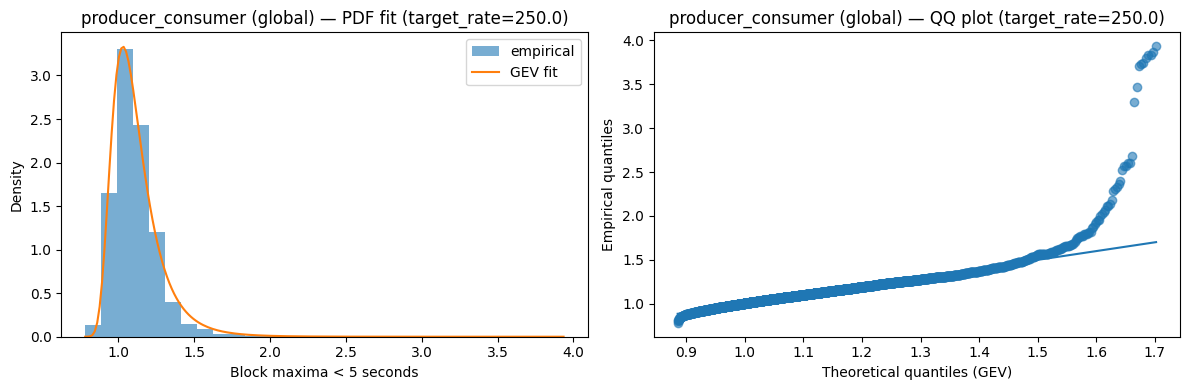


Metric=consumer_application | Scope=global | TARGET_RATE=250.0 | n=3919
GEV fit: c=1.0046, loc=0.0200, scale=0.0000 | KS D=0.0084, p=0.9401


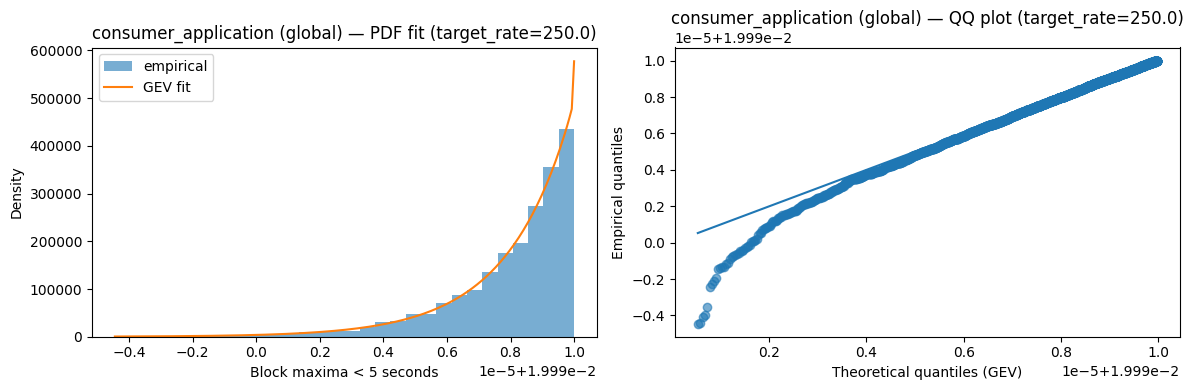

In [28]:
# -----------------------------
# Fit & Plot per metric
# -----------------------------

SCOPE    = "global"
metrics  = ["producer_consumer", "consumer_application"]
plot_dir = os.path.join(Home,"plots", f"plots_tr{TARGET_RATE}")
os.makedirs(plot_dir, exist_ok=True)

for metric in metrics:
    mask = (block_df["metric"] == metric)
    nrows = int(mask.sum())
    if nrows == 0:
        print(f"⚠️  No rows for metric={metric} at scope={SCOPE}.")
        continue

    data = block_df.loc[mask, "block_max_value"].dropna().astype(float).values
    if len(data) < 5:
        print(f"⚠️  Not enough data for metric={metric} (n={len(data)}). Skipping.")
        continue

    # Fit GEV + KS
    c, loc, scale = genextreme.fit(data)
    D, p = kstest(data, 'genextreme', args=(c, loc, scale))
    print(f"\nMetric={metric} | Scope={SCOPE} | TARGET_RATE={TARGET_RATE} | n={len(data)}")
    print(f"GEV fit: c={c:.4f}, loc={loc:.4f}, scale={scale:.4f} | KS D={D:.4f}, p={p:.4f}")

    # ---- Plot (one figure per metric) ----
    fig = plt.figure(figsize=(12, 4))
    
    # Left: histogram + fitted PDF
    ax1 = plt.subplot(1, 2, 1)
    x = np.linspace(float(np.min(data)), float(np.max(data)), 200)
    pdf = genextreme.pdf(x, c, loc=loc, scale=scale)
    ax1.hist(data, bins=30, density=True, alpha=0.6, label="empirical")
    ax1.plot(x, pdf, label="GEV fit")
    ax1.set_title(f"{metric} ({SCOPE}) — PDF fit (target_rate={TARGET_RATE})")
    ax1.set_xlabel(f"Block maxima < {CAP_S} seconds")
    ax1.set_ylabel("Density")
    ax1.legend()

    # Right: QQ-plot
    ax2 = plt.subplot(1, 2, 2)
    emp_q = np.sort(data)
    theo_q = genextreme.ppf(np.linspace(0.02, 0.98, len(emp_q)), c, loc=loc, scale=scale)
    ax2.scatter(theo_q, emp_q, alpha=0.6)
    lo, hi = np.nanmin(theo_q), np.nanmax(theo_q)
    ax2.plot([lo, hi], [lo, hi])
    ax2.set_title(f"{metric} ({SCOPE}) — QQ plot (target_rate={TARGET_RATE})")
    ax2.set_xlabel("Theoretical quantiles (GEV)")
    ax2.set_ylabel("Empirical quantiles")

    plt.tight_layout()

    out_path = os.path.join(plots_dir, f"pdfqq_notrim_tr{TARGET_RATE}.png")
    plt.savefig(out_path, dpi=150)
    plt.show()
    #print(f"[INFO] Saved plot to {out_path}")


In [29]:
def trim_top_pct(arr, pct):
    if pct <= 0:
        return arr
    cut = np.nanpercentile(arr, 100 * (1.0 - pct))
    return arr[arr <= cut]
    
def fit_and_ks(x):
    c, loc, scale = genextreme.fit(x)
    D, p = kstest(x, 'genextreme', args=(c, loc, scale))
    return c, loc, scale, D, p


=== producer_consumer (scope=global, target_rate=250.0) ===
 trim=  0%: n=3891  KS D=0.0312  p=0.0010  (c=-0.1071, loc=1.0420, scale=0.1110)
 trim=  1%: n=3852  KS D=0.0096  p=0.8649  (c=+0.0123, loc=1.0453, scale=0.1078)
 trim=  2%: n=3813  KS D=0.0100  p=0.8352  (c=+0.0695, loc=1.0459, scale=0.1059)
 trim=  5%: n=3696  KS D=0.0239  p=0.0293  (c=+0.1844, loc=1.0458, scale=0.1018)
 trim=  7%: n=3618  KS D=0.0271  p=0.0098  (c=+0.2321, loc=1.0446, scale=0.0993)
 trim= 10%: n=3502  KS D=0.0265  p=0.0142  (c=+0.2831, loc=1.0420, scale=0.0959)


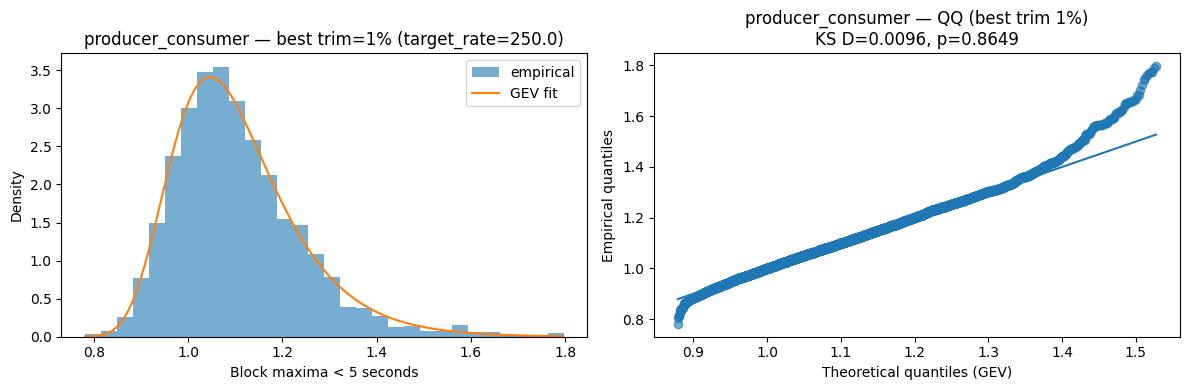

[PLOT] Saved /Users/soheila/Desktop/RealTime-Streaming-Pipeline/results/plots/20250909-1614/best_trim1_tr250.0_global.png

=== consumer_application (scope=global, target_rate=250.0) ===
 trim=  0%: n=3919  KS D=0.0084  p=0.9401  (c=+1.0046, loc=0.0200, scale=0.0000)
 trim=  1%: n=3879  KS D=0.0075  p=0.9791  (c=+1.0040, loc=0.0200, scale=0.0000)
 trim=  2%: n=3840  KS D=0.0081  p=0.9625  (c=+1.0072, loc=0.0200, scale=0.0000)
 trim=  5%: n=3723  KS D=0.0076  p=0.9811  (c=+1.0012, loc=0.0200, scale=0.0000)
 trim=  7%: n=3644  KS D=0.0164  p=0.2774  (c=+0.9661, loc=0.0200, scale=0.0000)
 trim= 10%: n=3527  KS D=0.0105  p=0.8290  (c=+0.9904, loc=0.0200, scale=0.0000)


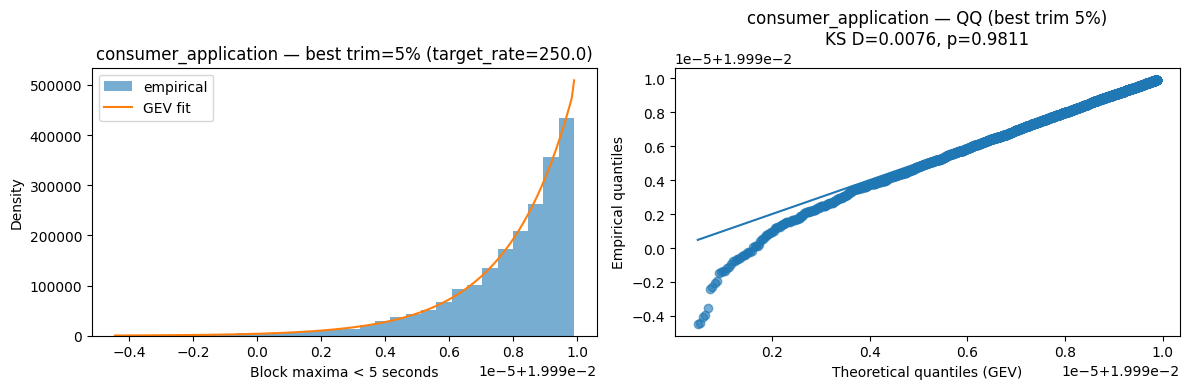

[PLOT] Saved /Users/soheila/Desktop/RealTime-Streaming-Pipeline/results/plots/20250909-1614/best_trim5_tr250.0_global.png

=== Best trim per metric (by KS p-value) ===
producer_consumer       trim= 1%  n=3852  KS D=0.0096  p=0.8649  c=+0.0123  loc=1.0453  scale=0.1078
consumer_application    trim= 5%  n=3723  KS D=0.0076  p=0.9811  c=+1.0012  loc=0.0200  scale=0.0000


In [30]:
# ---------- Trim Data & plotting ----------

results  = []
plot_dir = os.path.join(Home, "plots")
os.makedirs(plot_dir, exist_ok=True)

for metric in metrics:
    raw = block_df.loc[block_df["metric"] == metric, "block_max_value"].dropna().astype(float).values
    if raw.size < 10:
        print(f"⚠️ Not enough data for {metric} (n={raw.size}). Skipping.")
        continue

    best = None  # (p, D, c, loc, scale, pct, n)
    print(f"\n=== {metric} (scope={SCOPE}, target_rate={TARGET_RATE}) ===")
    for pct in trim_levels:
        x = trim_top_pct(raw, pct)
        if x.size < 10:
            print(f" trim={pct:>4.0%}: n={x.size:4d}  -> skip (too few)")
            continue
        c, loc, scale, D, p = fit_and_ks(x)
        print(f" trim={pct:>4.0%}: n={x.size:4d}  KS D={D:0.4f}  p={p:0.4f}  (c={c:+.4f}, loc={loc:.4f}, scale={scale:.4f})")
        if (best is None) or (p > best[0]):
            best = (p, D, c, loc, scale, pct, x.size)

    if best is None:
        continue
    p, D, c, loc, scale, pct, n = best
    results.append({
        "metric": metric, "best_trim": pct, "n": n,
        "KS_D": D, "KS_p": p, "c": c, "loc": loc, "scale": scale
    })

    # plot ONLY best trim
    xdat = trim_top_pct(raw, pct)
    fig = plt.figure(figsize=(12,4))

    # PDF overlay
    ax1 = plt.subplot(1,2,1)
    xx = np.linspace(float(np.min(xdat)), float(np.max(xdat)), 200)
    pdf = genextreme.pdf(xx, c, loc=loc, scale=scale)
    ax1.hist(xdat, bins=30, density=True, alpha=0.6, label="empirical")
    ax1.plot(xx, pdf, label="GEV fit")
    ax1.set_title(f"{metric} — best trim={int(pct*100)}% (target_rate={TARGET_RATE})")
    ax1.set_xlabel(f"Block maxima < {CAP_S} seconds"); ax1.set_ylabel("Density"); ax1.legend()
    # QQ
    ax2 = plt.subplot(1,2,2)
    emp_q  = np.sort(xdat)
    theo_q = genextreme.ppf(np.linspace(0.02, 0.98, len(emp_q)), c, loc=loc, scale=scale)
    ax2.scatter(theo_q, emp_q, alpha=0.6)
    lo, hi = np.nanmin(theo_q), np.nanmax(theo_q)
    ax2.plot([lo, hi], [lo, hi])
    ax2.set_title(f"{metric} — QQ (best trim {int(pct*100)}%)\nKS D={D:.4f}, p={p:.4f}")
    ax2.set_xlabel("Theoretical quantiles (GEV)"); ax2.set_ylabel("Empirical quantiles")

    plt.tight_layout()
    out_path = os.path.join(plots_dir, f"best_trim{int(pct*100)}_tr{TARGET_RATE}_{SCOPE}.png")
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f"[PLOT] Saved {out_path}")
    
# quick summary
if results:
    print("\n=== Best trim per metric (by KS p-value) ===")
    for r in results:
        print(f"{r['metric']:22s}  trim={int(r['best_trim']*100):2d}%  n={r['n']:4d}  "
              f"KS D={r['KS_D']:.4f}  p={r['KS_p']:.4f}  "
              f"c={r['c']:+.4f}  loc={r['loc']:.4f}  scale={r['scale']:.4f}")
else:
    print("No results to summarize.")

[PLOT] Saved /Users/soheila/Desktop/RealTime-Streaming-Pipeline/results/plots/20250909-1614/best_trim5_tr250.0_global.png


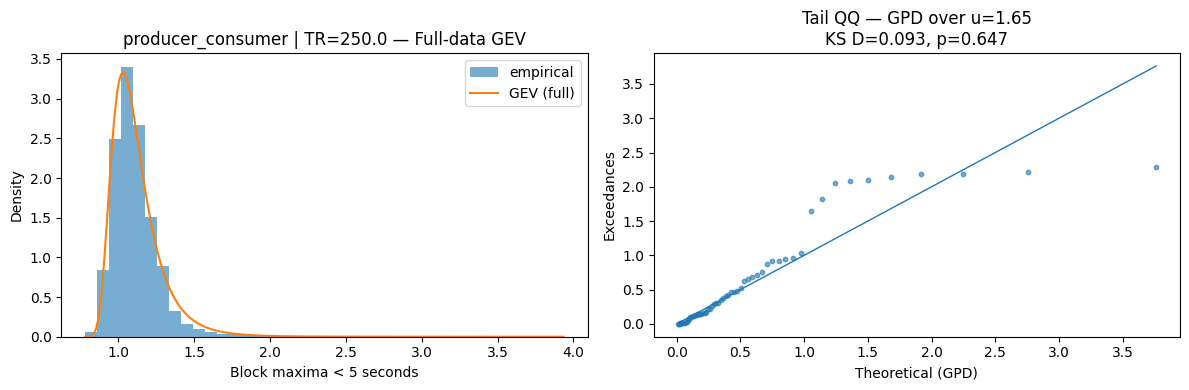

[PLOT] /Users/soheila/Desktop/RealTime-Streaming-Pipeline/results/plots/20250909-1614/gev_gpd_producer_consumer_tr250.0.png
[PLOT] Saved /Users/soheila/Desktop/RealTime-Streaming-Pipeline/results/plots/20250909-1614/best_trim5_tr250.0_global.png


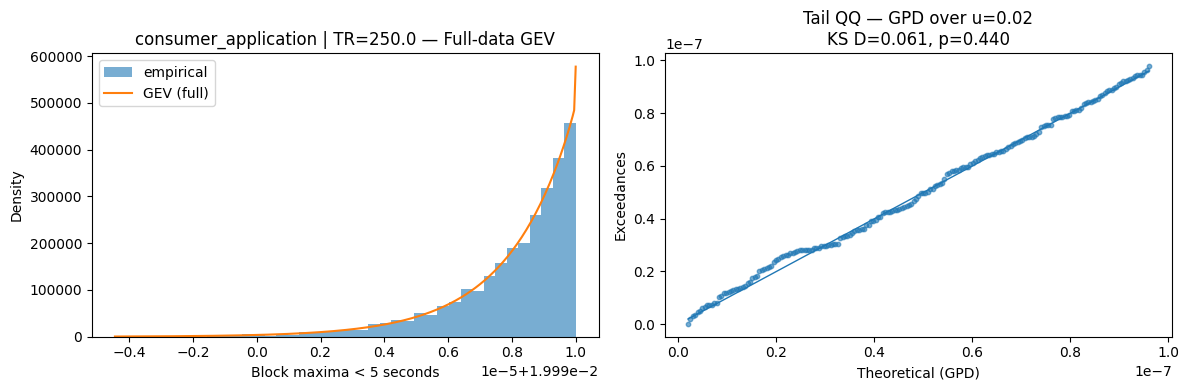

[PLOT] /Users/soheila/Desktop/RealTime-Streaming-Pipeline/results/plots/20250909-1614/gev_gpd_consumer_application_tr250.0.png
[RESULT] Wrote summary → /Users/soheila/Desktop/RealTime-Streaming-Pipeline/results/evt_no_trim_results/tr_250/evt_fit_summary.csv

=== consumer_application ===
TR=250 | n=3919 | GEV p=0.940 | GPD tail n_exc=196 p=0.4395994902093424 | Lomax-whole p=0.000

=== producer_consumer ===
TR=250 | n=3891 | GEV p=0.001 | GPD tail n_exc=59 p=0.6470075400570199 | Lomax-whole p=0.000


In [32]:
# === EVT without trimming: Full-data GEV + Tail GPD (Pareto) + (optional) whole-data Lomax ===

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ---------- Utility: AIC/BIC ----------
def aic_bic_from_logpdf(logpdf_vals, k_params: int) -> Tuple[float, float]:
    n = np.isfinite(logpdf_vals).sum()
    ll = np.nansum(logpdf_vals)  # total log-likelihood
    aic = 2*k_params - 2*ll
    bic = k_params * np.log(max(n, 1)) - 2*ll
    return float(aic), float(bic)

# ---------- Utility: GEV fit on full data (no trim) ----------
def fit_gev_full(x: np.ndarray) -> Dict[str, float]:
    c, loc, scale = genextreme.fit(x)
    D, p = kstest(x, 'genextreme', args=(c, loc, scale))
    # AIC/BIC
    xx = np.asarray(x, float)
    logpdf = genextreme.logpdf(xx, c, loc=loc, scale=scale)
    aic, bic = aic_bic_from_logpdf(logpdf, k_params=3)
    return dict(c=c, loc=loc, scale=scale, KS_D=D, KS_p=p, AIC=aic, BIC=bic)

# ---------- Utility: choose threshold from "best_trim" (fall back to 95th) ----------
def threshold_from_best_trim(x: np.ndarray, best_trim: float, fallback_q: float = 0.95) -> float:
    if best_trim is None or best_trim <= 0.0:
        q = fallback_q
    else:
        q = 1.0 - best_trim
        # keep thresholds reasonable
        q = min(max(q, 0.80), 0.985)
    return float(np.nanpercentile(x, q*100.0))

# ---------- Utility: Tail fit with GPD (Pareto) on exceedances ----------
def fit_gpd_tail(x: np.ndarray, u: float, min_exc: int = 50) -> Optional[Dict[str, float]]:
    exc = x[x > u] - u   # exceedances above u
    exc = exc[np.isfinite(exc)]
    n_exc = exc.size
    if n_exc < min_exc:
        return None
    # Fit GPD with loc=0 (exceedances by definition start at 0)
    shape, loc, scale = genpareto.fit(exc, floc=0)
    # GOF on exceedances
    D, p = kstest(exc, 'genpareto', args=(shape, 0, scale))
    # AIC/BIC for tail model only
    logpdf = genpareto.logpdf(exc, shape, 0, scale)
    aic, bic = aic_bic_from_logpdf(logpdf, k_params=2)  # (shape, scale) since loc fixed at 0
    return dict(xi=shape, beta=scale, KS_D=D, KS_p=p, AIC=aic, BIC=bic, u=u, n_exc=n_exc)

# ---------- Optional: Whole-data Lomax (Pareto II) check ----------
def fit_lomax_whole(x: np.ndarray) -> Dict[str, float]:
    # shift so support starts at 0
    x0 = np.min(x)
    y = x - x0
    # Fit Lomax with floc=0
    shape, loc, scale = lomax.fit(y, floc=0)
    D, p = kstest(y, 'lomax', args=(shape, 0, scale))
    logpdf = lomax.logpdf(y, shape, 0, scale)
    aic, bic = aic_bic_from_logpdf(logpdf, k_params=2)
    return dict(alpha=shape, scale=scale, x_shift=x0, KS_D=D, KS_p=p, AIC=aic, BIC=bic)

# ---------- Optional: quick "best trim" search you already used (we won't trim in final fits) ----------
def trim_top_pct(arr, pct):
    if pct <= 0:
        return arr
    cut = np.nanpercentile(arr, 100 * (1.0 - pct))
    return arr[arr <= cut]

def best_trim_by_ks(x: np.ndarray, trim_levels=(0.00, 0.01, 0.02, 0.05, 0.07, 0.10)) -> Tuple[float, dict]:
    """Return (best_trim, best_result_dict) where best is by highest KS p-value for GEV."""
    best = None
    best_trim = 0.0
    for pct in trim_levels:
        xt = trim_top_pct(x, pct)
        if xt.size < 10:
            continue
        c, loc, scale = genextreme.fit(xt)
        D, p = kstest(xt, 'genextreme', args=(c, loc, scale))
        if (best is None) or (p > best["KS_p"]):
            best = dict(c=c, loc=loc, scale=scale, KS_D=D, KS_p=p, n=len(xt), trim=pct)
            best_trim = pct
    return best_trim, best or {}

# ---------- Plot helpers ----------
def plot_full_and_tail(x, gev_params, gpd_params, metric, tr, outdir):
    os.makedirs(outdir, exist_ok=True)
    # Full-data: histogram + GEV pdf
    fig = plt.figure(figsize=(12,4))
    ax1 = plt.subplot(1,2,1)
    xx = np.linspace(float(np.min(x)), float(np.max(x)), 300)
    pdf_gev = genextreme.pdf(xx, gev_params["c"], loc=gev_params["loc"], scale=gev_params["scale"])
    ax1.hist(x, bins=40, density=True, alpha=0.6, label="empirical")
    ax1.plot(xx, pdf_gev, label="GEV (full)")
    ax1.set_title(f"{metric} | TR={tr} — Full-data GEV")
    ax1.set_xlabel(f"Block maxima < {CAP_S} seconds"); ax1.set_ylabel("Density"); ax1.legend()

    # Tail QQ for GPD
    ax2 = plt.subplot(1,2,2)
    if gpd_params is not None:
        u = gpd_params["u"]
        exc = x[x > u] - u
        exc = np.sort(exc)
        q = np.linspace(0.02, 0.98, len(exc))
        theo = genpareto.ppf(q, gpd_params["xi"], 0, gpd_params["beta"])
        ax2.scatter(theo, exc, s=10, alpha=0.6, label=f"GPD tail (n_exc={len(exc)})")
        lo, hi = float(np.nanmin(theo)), float(np.nanmax(theo))
        ax2.plot([lo, hi], [lo, hi], lw=1)
        ax2.set_title(f"Tail QQ — GPD over u={u:.4g}\nKS D={gpd_params['KS_D']:.3f}, p={gpd_params['KS_p']:.3f}")
        ax2.set_xlabel("Theoretical (GPD)"); ax2.set_ylabel("Exceedances")
    else:
        ax2.text(0.5, 0.5, "Not enough exceedances for GPD", ha="center", va="center")
        ax2.set_title("Tail QQ — GPD")
        ax2.set_xticks([]); ax2.set_yticks([])

    plt.tight_layout()
    out_png = os.path.join(plots_dir, f"gev_gpd_{metric}_tr{tr}.png")
    print(f"[PLOT] Saved {out_path}")
    plt.savefig(out_png, dpi=150)
    plt.show()
    print(f"[PLOT] {out_png}")

# ---------- Main analysis over metrics × target rates ----------
def analyze_evt_no_trim(block_df: pd.DataFrame,
                        metrics=("producer_consumer","consumer_application"),
                        min_exc=50,
                        trim_levels=(0.00,0.01,0.02,0.05,0.07,0.10),
                        out_dir=os.path.join(Home, "evt_no_trim_results")):
    os.makedirs(out_dir, exist_ok=True)

    if "target_rate" not in block_df.columns:
        raise ValueError("block_df must have 'target_rate' (merge parquet metadata first).")

    results = []
    for metric in metrics:
        msk_metric = (block_df["metric"] == metric)
        for tr in sorted(block_df.loc[msk_metric, "target_rate"].dropna().unique()):
            data = block_df.loc[msk_metric & (block_df["target_rate"]==tr), "block_max_value"].dropna().astype(float).values
            if data.size < 20:
                print(f"⚠️  {metric} | TR={tr}: too few points (n={data.size}). Skipping.")
                continue

            # 1) Full-data GEV
            gev = fit_gev_full(data)

            # 2) Best trim (to INFORM threshold only; we DO NOT trim the final GEV fit)
            best_trim, best_trim_info = best_trim_by_ks(data, trim_levels=trim_levels)
            u = threshold_from_best_trim(data, best_trim, fallback_q=0.95)

            # 3) Tail GPD (Pareto) over threshold
            gpd_tail = fit_gpd_tail(data, u, min_exc=min_exc)

            # 4) Whole-data Lomax (Pareto II) sanity check
            lom = fit_lomax_whole(data)

            # 5) Plots
            plot_dir = os.path.join(out_dir, f"tr_{int(tr)}")
            plot_full_and_tail(data, gev, gpd_tail, metric, tr, plot_dir)

            # 6) Collect summary
            row = {
                "metric": metric, "target_rate": tr, "n": int(len(data)),
                # Full GEV
                "gev_c": gev["c"], "gev_loc": gev["loc"], "gev_scale": gev["scale"],
                "gev_KS_D": gev["KS_D"], "gev_KS_p": gev["KS_p"], "gev_AIC": gev["AIC"], "gev_BIC": gev["BIC"],
                # Best-trim (for threshold selection only)
                "best_trim_pct": best_trim,
                "u_threshold": u,
                # Tail GPD
                "gpd_xi": np.nan, "gpd_beta": np.nan, "gpd_KS_D": np.nan, "gpd_KS_p": np.nan,
                "gpd_AIC": np.nan, "gpd_BIC": np.nan, "gpd_n_exc": 0,
                # Whole-data Lomax
                "lomax_alpha": lom["alpha"], "lomax_scale": lom["scale"], "lomax_shift": lom["x_shift"],
                "lomax_KS_D": lom["KS_D"], "lomax_KS_p": lom["KS_p"], "lomax_AIC": lom["AIC"], "lomax_BIC": lom["BIC"],
            }
            if gpd_tail is not None:
                row.update({
                    "gpd_xi": gpd_tail["xi"], "gpd_beta": gpd_tail["beta"],
                    "gpd_KS_D": gpd_tail["KS_D"], "gpd_KS_p": gpd_tail["KS_p"],
                    "gpd_AIC": gpd_tail["AIC"], "gpd_BIC": gpd_tail["BIC"],
                    "gpd_n_exc": int(gpd_tail["n_exc"]),
                })
            results.append(row)

    res_df = pd.DataFrame(results).sort_values(["metric","target_rate"])
    out_csv = os.path.join(out_dir, f"tr_{int(tr)}", "evt_fit_summary.csv")
    res_df.to_csv(out_csv, index=False)
    print(f"[RESULT] Wrote summary → {out_csv}")

    # Quick guidance printout
    for metric in res_df["metric"].unique():
        sub = res_df[res_df["metric"]==metric]
        print(f"\n=== {metric} ===")
        for _, r in sub.iterrows():
            print(f"TR={int(r['target_rate'])} | n={int(r['n'])} | "
                  f"GEV p={r['gev_KS_p']:.3f} | GPD tail n_exc={int(r['gpd_n_exc'])} p={r['gpd_KS_p'] if pd.notna(r['gpd_KS_p']) else np.nan} | "
                  f"Lomax-whole p={r['lomax_KS_p']:.3f}")

    return res_df

# --------- RUN IT (uses your block_df with target_rate already merged) ----------
evt_summary_df = analyze_evt_no_trim(block_df,
                                     metrics=("producer_consumer","consumer_application"),
                                     min_exc=50,
                                     trim_levels=tuple(trim_levels),
                                     out_dir=os.path.join(Home, "evt_no_trim_results"))


In [ ]:
import os, time, numpy as np, pandas as pd
from scipy.stats import genextreme, genpareto, kstest

# ---- paths (edit these) ----
RUN_ROOT      = "20250908_140639>"
METRICS      = ("producer_consumer", "consumer_application")
SCOPES       = ("global") #, "consumer_pod", "producer_pod")
SCOPE        = "global"
Home         = "/Users/soheila/Desktop/RealTime-Streaming-Pipeline/results"
RUN_ROOT    = "20250908_140639"             
PARQUET_ROOT = os.path.join(Home, RUN_ROOT, "consumer", "consumer-sts-0_consumer-result/processed/2025-09-08")


OUT_DIR    = os.path.join( Home, "plots", current_datetime)
os.makedirs(OUT_DIR, exist_ok=True)
 

CAP_S = 5.0  # drop latencies outside [0, 5] s for this synthetic run

# ---- helpers ----
def list_parquet_files(root):
    for r,_,fs in os.walk(root):
        for f in fs:
            if f.endswith(".parquet") and not f.startswith(".tmp_"):
                yield os.path.join(r,f)

NEEDED = {
    "producer_timestamp","consumer_receive_timestamp",
    "application_timestamp","application_latency_seconds",
    "end_to_end_latency_seconds","producer_pod","consumer_pod"
}

def load_cols(p):
    try:
        import pyarrow.parquet as pq
        have = set(pq.read_schema(p).names)
        cols = list(NEEDED & have)
        if not cols: return pd.DataFrame()
        return pd.read_parquet(p, columns=cols)
    except Exception:
        try:
            df = pd.read_parquet(p)
            keep = list(NEEDED & set(df.columns))
            return df[keep] if keep else pd.DataFrame()
        except Exception:
            return pd.DataFrame()

def metric_series(df):
    out = {}
    # producer_consumer
    if {"producer_timestamp","consumer_receive_timestamp"}.issubset(df.columns):
        s = (pd.to_numeric(df["consumer_receive_timestamp"], errors="coerce") -
             pd.to_numeric(df["producer_timestamp"], errors="coerce")).dropna()
        s = s[(s>=0) & (s<=CAP_S)]
        if not s.empty: out["producer_consumer"] = s
    # consumer_application
    if "application_latency_seconds" in df.columns:
        s = pd.to_numeric(df["application_latency_seconds"], errors="coerce").dropna()
        s = s[(s>=0) & (s<=CAP_S)]
        if not s.empty: out["consumer_application"] = s
    elif {"application_timestamp","consumer_receive_timestamp"}.issubset(df.columns):
        s = (pd.to_numeric(df["application_timestamp"], errors="coerce") -
             pd.to_numeric(df["consumer_receive_timestamp"], errors="coerce")).dropna()
        s = s[(s>=0) & (s<=CAP_S)]
        if not s.empty: out["consumer_application"] = s
    # producer_application
    if "end_to_end_latency_seconds" in df.columns:
        s = pd.to_numeric(df["end_to_end_latency_seconds"], errors="coerce").dropna()
        s = s[(s>=0) & (s<=CAP_S)]
        if not s.empty: out["producer_application"] = s
    elif {"application_timestamp","producer_timestamp"}.issubset(df.columns):
        s = (pd.to_numeric(df["application_timestamp"], errors="coerce") -
             pd.to_numeric(df["producer_timestamp"], errors="coerce")).dropna()
        s = s[(s>=0) & (s<=CAP_S)]
        if not s.empty: out["producer_application"] = s
    return out

# ---- recompute block maxima rows (global scope) ----
rows = []
for root in PARQUET_ROOTS:
    if not os.path.exists(root): continue
    for p in list_parquet_files(root):
        df = load_cols(p)
        if df is None or df.empty: continue
        ser = metric_series(df)
        for metric, s in ser.items():
            rows.append({
                "file_name": os.path.basename(p),
                "computed_at": time.time(),
                "metric": metric,
                "scope": "global",
                "pod": "",
                "block_max_value": float(s.max()),
                "rows_in_block": int(s.shape[0]),
            })

bm = pd.DataFrame(rows)
bm_path = os.path.join(OUT_DIR, "block_maxima_clean.csv")
bm.to_csv(bm_path, index=False)
print(f"[SAVE] {bm_path}  n_rows={len(bm)}")

# ---- GEV fit on cleaned maxima ----
fit_rows=[]
for m, g in bm[bm["scope"]=="global"].groupby("metric"):
    x = g["block_max_value"].dropna().astype(float).values
    if len(x)<30: continue
    c, loc, scale = genextreme.fit(x)
    D, p = kstest(x, 'genextreme', args=(c, loc, scale))
    fit_rows.append({"metric": m, "n_blocks": len(x), "c": c, "loc": loc, "scale": scale, "KS_D": D, "KS_p": p})
gev_path = os.path.join(OUT_DIR, "gev_fit_results_clean.csv")
pd.DataFrame(fit_rows).to_csv(gev_path, index=False)
print(f"[SAVE] {gev_path}")

# ---- Simple POT on cleaned maxima (tail over a high quantile) ----
def ks_gpd(ex):
    if len(ex)<30: return np.nan, np.nan, np.nan, np.nan
    xi, loc, beta = genpareto.fit(ex, floc=0.0)
    D, p = kstest(ex, 'genpareto', args=(xi, 0.0, beta))
    return xi, beta, D, p

pot_rows=[]
for m, g in bm.groupby("metric"):
    x = np.asarray(g["block_max_value"].dropna().astype(float).values)
    if x.size < 100: continue
    # grid of high quantiles; pick best by KS p
    best=None
    for q in [0.95,0.96,0.97,0.98,0.985,0.99]:
        u = np.quantile(x, q)
        ex = x[x>u] - u
        if ex.size<30: continue
        xi, beta, D, p = ks_gpd(ex)
        row = {"metric": m, "q": q, "u": u, "n_exc": len(ex), "xi": xi, "beta": beta, "KS_D": D, "KS_p": p}
        pot_rows.append(row)
        if best is None or (np.isfinite(p) and p > best["KS_p"]):
            best = row
    if best is not None:
        print(f"[POT] {m}: best q={best['q']:.3f}, u={best['u']:.4g}, n_exc={best['n_exc']}, xi={best['xi']:.3f}, beta={best['beta']:.3f}, KS p={best['KS_p']:.3f}")

pd.DataFrame(pot_rows).to_csv(os.path.join(OUT_DIR, "gpd_threshold_scan_clean.csv"), index=False)
